In [ ]:
from transformers import BertTokenizer, AutoModelForSequenceClassification

# Use pre-trained FinBERT model
tokenizer = BertTokenizer.from_pretrained("ProsusAI/finbert")
model = AutoModelForSequenceClassification.from_pretrained(
    "ProsusAI/finbert",
    num_labels=5,   # 5-class labels
    ignore_mismatched_sizes=True # Key parameter
)

# Define tokenize function
def tokenize(batch):
    return tokenizer(batch["text"], padding="max_length", truncation=True, max_length=512)

# Assume you already have train.csv and val.csv
from datasets import load_dataset
dataset = load_dataset("csv", data_files={"train": "train_5class.csv", "validation": "val_5class.csv"})

# Apply tokenization
tokenized_dataset = dataset.map(tokenize, batched=True)

# Set PyTorch format
tokenized_dataset.set_format("torch", columns=["input_ids", "attention_mask", "label"])

from transformers import TrainingArguments


training_args = TrainingArguments(
    output_dir="./finbert_finetuned",
    do_train=True,
    do_eval=True,
    eval_strategy="epoch",          # Old parameter name
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_dir="./logs",
    logging_steps=50,
    save_steps=500,
    eval_steps=500
)


from transformers import Trainer

trainer = Trainer(
    model=model,  # Your previously loaded AutoModelForSequenceClassification(num_labels=5, ignore_mismatched_sizes=True)
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
)

trainer.train()

trainer.save_model("./finbert_finetuned")
tokenizer.save_pretrained("./finbert_finetuned")
print("Final model saved to ./finbert_finetuned")


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at ProsusAI/finbert and are newly initialized because the shapes did not match:
- classifier.weight: found shape torch.Size([3, 768]) in the checkpoint and torch.Size([5, 768]) in the model instantiated
- classifier.bias: found shape torch.Size([3]) in the checkpoint and torch.Size([5]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Map:   0%|          | 0/22475 [00:00<?, ? examples/s]

Map:   0%|          | 0/5619 [00:00<?, ? examples/s]

Epoch,Training Loss,Validation Loss
1,1.582600,1.572939
2,1.546100,1.558311
3,1.428100,1.559585


最终模型已保存到 ./finbert_finetuned


In [ ]:
from transformers import BertTokenizer, AutoModelForSequenceClassification
from transformers import TrainingArguments

# Use pre-trained FinBERT model
tokenizer = BertTokenizer.from_pretrained("ProsusAI/finbert")
model = AutoModelForSequenceClassification.from_pretrained(
    "ProsusAI/finbert",
    num_labels=3,   # 3-class labels
    ignore_mismatched_sizes=True # Key parameter
)

# Define tokenize function
def tokenize(batch):
    return tokenizer(batch["text"], padding="max_length", truncation=True, max_length=512)

# Assume you already have train.csv and val.csv
from datasets import load_dataset
dataset = load_dataset("csv", data_files={"train": "train_3class.csv", "validation": "val_3class.csv"})

# Apply tokenization
tokenized_dataset = dataset.map(tokenize, batched=True)

# Set PyTorch format
tokenized_dataset.set_format("torch", columns=["input_ids", "attention_mask", "label"])


training_args = TrainingArguments(
    output_dir="./finbert_finetuned_3class",
    do_train=True,
    do_eval=True,
    eval_strategy="epoch",          
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_dir="./logs",
    logging_steps=50,
    save_steps=500,
    eval_steps=500
)


from transformers import Trainer

trainer = Trainer(
    model=model,  # Your previously loaded AutoModelForSequenceClassification(num_labels=3, ignore_mismatched_sizes=True)
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
)

trainer.train()

trainer.save_model("./finbert_finetuned_3class")
tokenizer.save_pretrained("./finbert_finetuned_3class")
print("Final model saved to ./finbert_finetuned_3class")


Epoch,Training Loss,Validation Loss
1,1.061600,1.078310
2,1.044300,1.052849
3,0.993000,1.069945


最终模型已保存到 ./finbert_finetuned_3class


In [ ]:
from transformers import BertTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from datasets import load_dataset
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Use FinBERT model
tokenizer = BertTokenizer.from_pretrained("ProsusAI/finbert")

def tokenize(batch):
    return tokenizer(batch["text"], padding="max_length", truncation=True, max_length=512)

# Load time-series split data
dataset = load_dataset("csv", data_files={
    "train": "train_timeseries_5class.csv",
    "validation": "val_timeseries_5class.csv"
})

# Tokenization
tokenized_dataset = dataset.map(tokenize, batched=True)
tokenized_dataset.set_format("torch", columns=["input_ids", "attention_mask", "label"])

# Define training parameters
training_args = TrainingArguments(
    output_dir="./finbert_timeseries",
    overwrite_output_dir=True,
    do_train=True,
    do_eval=True,
    eval_strategy="epoch",   # Note: check your version for eval_strategy
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_dir="./logs",
    logging_steps=50,
    save_steps=500,
    eval_steps=500
)

# Initialize model
model = AutoModelForSequenceClassification.from_pretrained(
    "ProsusAI/finbert",
    num_labels=5,
    ignore_mismatched_sizes=True
)

# Define Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
)

# Train
trainer.train()

# Save final model
trainer.save_model("./finbert_timeseries")
tokenizer.save_pretrained("./finbert_timeseries")
print("Final model saved to ./finbert_timeseries")


Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Map:   0%|          | 0/25320 [00:00<?, ? examples/s]

Map:   0%|          | 0/2774 [00:00<?, ? examples/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at ProsusAI/finbert and are newly initialized because the shapes did not match:
- classifier.weight: found shape torch.Size([3, 768]) in the checkpoint and torch.Size([5, 768]) in the model instantiated
- classifier.bias: found shape torch.Size([3]) in the checkpoint and torch.Size([5]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss
1,1.571400,1.599825
2,1.542400,1.631817
3,1.445300,1.689411


最终模型已保存到 ./finbert_timeseries


In [ ]:
from transformers import BertTokenizer, AutoModelForSequenceClassification
from transformers import TrainingArguments

# Use pre-trained FinBERT model
tokenizer = BertTokenizer.from_pretrained("ProsusAI/finbert")
model = AutoModelForSequenceClassification.from_pretrained(
    "ProsusAI/finbert",
    num_labels=3,   # 3-class labels
    ignore_mismatched_sizes=True # Key parameter
)

# Define tokenize function
def tokenize(batch):
    return tokenizer(batch["text"], padding="max_length", truncation=True, max_length=512)

# Assume you already have train.csv and val.csv
from datasets import load_dataset
dataset = load_dataset("csv", data_files={"train": "train_timeseries_3class.csv", "validation": "val_timeseries_3class.csv"})

# Apply tokenization
tokenized_dataset = dataset.map(tokenize, batched=True)

# Set PyTorch format
tokenized_dataset.set_format("torch", columns=["input_ids", "attention_mask", "label"])


training_args = TrainingArguments(
    output_dir="./finbert_timeseries_3class",
    do_train=True,
    do_eval=True,
    eval_strategy="epoch",          
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_dir="./logs",
    logging_steps=50,
    save_steps=500,
    eval_steps=500
)


from transformers import Trainer

trainer = Trainer(
    model=model,  # Your previously loaded AutoModelForSequenceClassification(num_labels=3, ignore_mismatched_sizes=True)
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
)

trainer.train()

trainer.save_model("./finbert_timeseries_3class")
tokenizer.save_pretrained("./finbert_timeseries_3class")
print("Final model saved to ./finbert_timeseries_3class")


Map:   0%|          | 0/25320 [00:00<?, ? examples/s]

Map:   0%|          | 0/2774 [00:00<?, ? examples/s]

Epoch,Training Loss,Validation Loss
1,1.072700,1.115006
2,1.047800,1.141906
3,0.971900,1.182555


最终模型已保存到 ./finbert_timeseries_3class


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at ProsusAI/finbert and are newly initialized because the shapes did not match:
- classifier.weight: found shape torch.Size([3, 768]) in the checkpoint and torch.Size([5, 768]) in the model instantiated
- classifier.bias: found shape torch.Size([3]) in the checkpoint and torch.Size([5]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Generating validation split: 0 examples [00:00, ? examples/s]

Map:   0%|          | 0/5619 [00:00<?, ? examples/s]

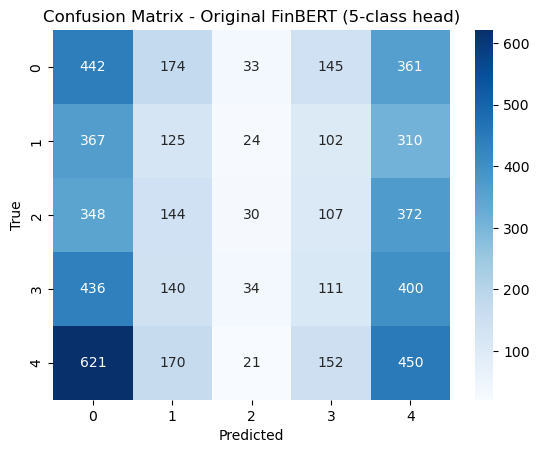

分类报告 - 原始 FinBERT (5 类头)
              precision    recall  f1-score   support

           0       0.20      0.38      0.26      1155
           1       0.17      0.13      0.15       928
           2       0.21      0.03      0.05      1001
           3       0.18      0.10      0.13      1121
           4       0.24      0.32      0.27      1414

    accuracy                           0.21      5619
   macro avg       0.20      0.19      0.17      5619
weighted avg       0.20      0.21      0.18      5619



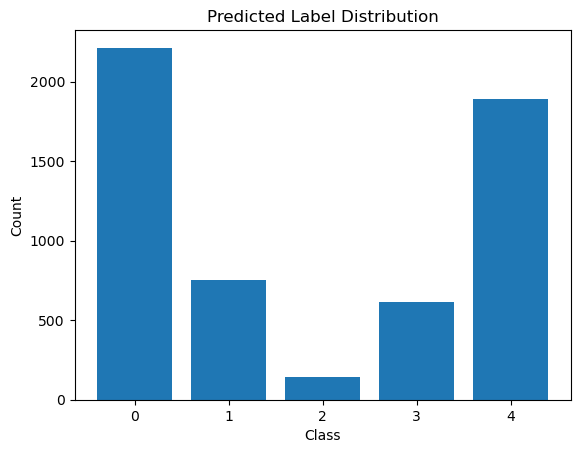

In [ ]:
import numpy as np
from transformers import BertTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from datasets import load_dataset
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. Specify model directory (original FinBERT)
model_dir = "ProsusAI/finbert"

# 2. Load tokenizer and model, replace classification head to 5 classes
tokenizer = BertTokenizer.from_pretrained(model_dir)
model = AutoModelForSequenceClassification.from_pretrained(
    model_dir,
    num_labels=5,                  # Replace with 5 classes
    ignore_mismatched_sizes=True   # Allow replacing classification layer
)

# 3. Load new validation set CSV
dataset = load_dataset("csv", data_files={"validation": "val_5class.csv"})
val_dataset = dataset["validation"]

# 4. Tokenization
def tokenize(batch):
    return tokenizer(batch["text"], padding="max_length", truncation=True, max_length=512)

tokenized_val = val_dataset.map(tokenize, batched=True)
tokenized_val.set_format("torch", columns=["input_ids", "attention_mask", "label"])

# 5. Define Trainer (prediction only, no training)
training_args = TrainingArguments(
    output_dir="./tmp_eval",
    do_train=False,
    do_eval=True,
    per_device_eval_batch_size=16,
)

trainer = Trainer(
    model=model,
    args=training_args,
    eval_dataset=tokenized_val,
)

# 6. Run predictions on validation set
predictions = trainer.predict(tokenized_val)
pred_labels = predictions.predictions.argmax(-1)
true_labels = predictions.label_ids

# 7. Visualize confusion matrix
cm = confusion_matrix(true_labels, pred_labels, labels=[0,1,2,3,4])
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=[0,1,2,3,4], yticklabels=[0,1,2,3,4])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Original FinBERT (5-class head)")
plt.show()

# 8. Classification report
print("Classification Report - Original FinBERT (5-class head)")
print(classification_report(true_labels, pred_labels, labels=[0,1,2,3,4]))

unique, counts = np.unique(pred_labels, return_counts=True)
plt.bar(unique, counts)
plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Predicted Label Distribution")
plt.show()


Map:   0%|          | 0/5619 [00:00<?, ? examples/s]

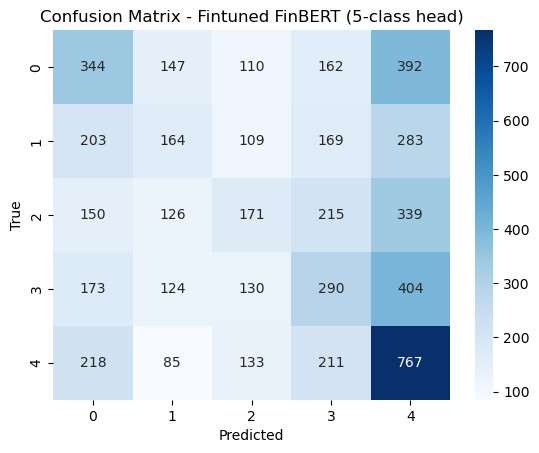

分类报告 - 微调后的 FinBERT (5 类头)
              precision    recall  f1-score   support

           0       0.32      0.30      0.31      1155
           1       0.25      0.18      0.21       928
           2       0.26      0.17      0.21      1001
           3       0.28      0.26      0.27      1121
           4       0.35      0.54      0.43      1414

    accuracy                           0.31      5619
   macro avg       0.29      0.29      0.28      5619
weighted avg       0.30      0.31      0.29      5619



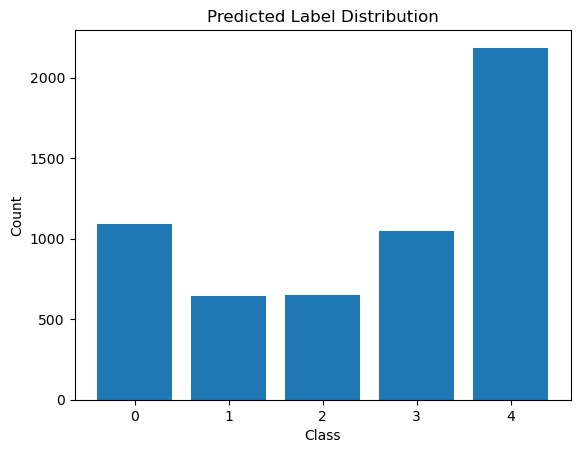

In [ ]:
from transformers import BertTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from datasets import load_dataset
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# 1. Specify model directory (fine-tuned FinBERT)
model_dir = "./finbert_finetuned"

# 2. Load tokenizer and model, replace classification head to 5 classes
tokenizer = BertTokenizer.from_pretrained(model_dir)
model = AutoModelForSequenceClassification.from_pretrained(
    model_dir,
    num_labels=5,                  # Replace with 5 classes
    ignore_mismatched_sizes=True   # Allow replacing classification layer
)

# 3. Load new validation set CSV
dataset = load_dataset("csv", data_files={"validation": "val_5class.csv"})
val_dataset = dataset["validation"]

# 4. Tokenization
def tokenize(batch):
    return tokenizer(batch["text"], padding="max_length", truncation=True, max_length=512)

tokenized_val = val_dataset.map(tokenize, batched=True)
tokenized_val.set_format("torch", columns=["input_ids", "attention_mask", "label"])

# 5. Define Trainer (prediction only, no training)
training_args = TrainingArguments(
    output_dir="./tmp_eval",
    do_train=False,
    do_eval=True,
    per_device_eval_batch_size=16,
)

trainer = Trainer(
    model=model,
    args=training_args,
    eval_dataset=tokenized_val,
)

# 6. Run predictions on validation set
predictions = trainer.predict(tokenized_val)
pred_labels = predictions.predictions.argmax(-1)
true_labels = predictions.label_ids

# 7. Visualize confusion matrix
cm = confusion_matrix(true_labels, pred_labels, labels=[0,1,2,3,4])
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=[0,1,2,3,4], yticklabels=[0,1,2,3,4])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Fine-tuned FinBERT (5-class head)")
plt.show()

# 8. Classification report
print("Classification Report - Fine-tuned FinBERT (5-class head)")
print(classification_report(true_labels, pred_labels, labels=[0,1,2,3,4]))

unique, counts = np.unique(pred_labels, return_counts=True)
plt.bar(unique, counts)
plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Predicted Label Distribution")
plt.show()


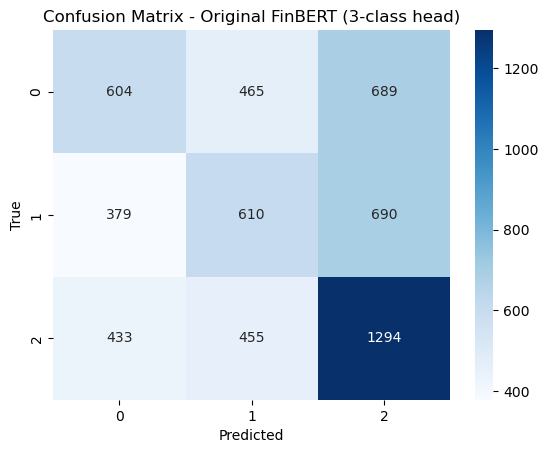

分类报告 - fintuned FinBERT (3类头)
              precision    recall  f1-score   support

           0       0.43      0.34      0.38      1758
           1       0.40      0.36      0.38      1679
           2       0.48      0.59      0.53      2182

    accuracy                           0.45      5619
   macro avg       0.44      0.43      0.43      5619
weighted avg       0.44      0.45      0.44      5619



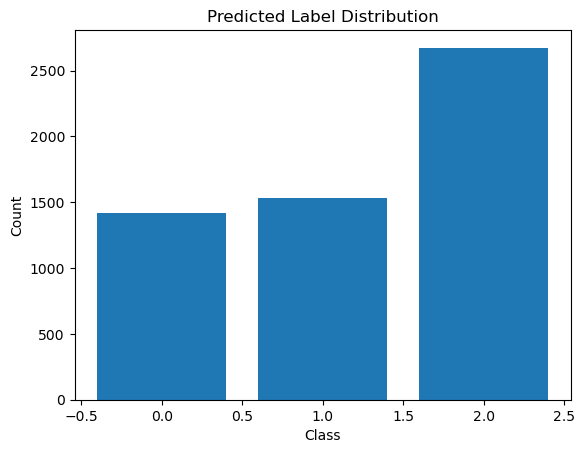

In [ ]:
import numpy as np
from transformers import BertTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from datasets import load_dataset
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. Specify model directory (fine-tuned FinBERT)
model_dir = "./finbert_finetuned_3class"

# 2. Load tokenizer and model, replace classification head to 3 classes
tokenizer = BertTokenizer.from_pretrained(model_dir)
model = AutoModelForSequenceClassification.from_pretrained(
    model_dir,
    num_labels=3,                  # Replace with 3 classes
    ignore_mismatched_sizes=True   # Allow replacing classification layer
)

# 3. Load new validation set CSV
dataset = load_dataset("csv", data_files={"validation": "val_3class.csv"})
val_dataset = dataset["validation"]

# 4. Tokenization
def tokenize(batch):
    return tokenizer(batch["text"], padding="max_length", truncation=True, max_length=512)

tokenized_val = val_dataset.map(tokenize, batched=True)
tokenized_val.set_format("torch", columns=["input_ids", "attention_mask", "label"])

# 5. Define Trainer (prediction only, no training)
training_args = TrainingArguments(
    output_dir="./tmp_eval",
    do_train=False,
    do_eval=True,
    per_device_eval_batch_size=16,
)

trainer = Trainer(
    model=model,
    args=training_args,
    eval_dataset=tokenized_val,
)

# 6. Run predictions on validation set
predictions = trainer.predict(tokenized_val)
pred_labels = predictions.predictions.argmax(-1)
true_labels = predictions.label_ids

# 7. Visualize confusion matrix
cm = confusion_matrix(true_labels, pred_labels, labels=[0,1,2])
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=[0,1,2], yticklabels=[0,1,2])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Fine-tuned FinBERT (3-class head)")
plt.show()

# 8. Classification report
print("Classification Report - Fine-tuned FinBERT (3-class head)")
print(classification_report(true_labels, pred_labels, labels=[0,1,2]))

unique, counts = np.unique(pred_labels, return_counts=True)
plt.bar(unique, counts)
plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Predicted Label Distribution")
plt.show()


Generating validation split: 0 examples [00:00, ? examples/s]

Map:   0%|          | 0/2774 [00:00<?, ? examples/s]

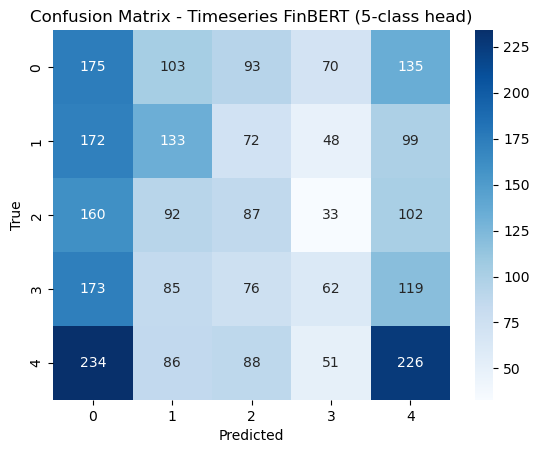

分类报告 - 时间序列的FinBERT (5 类头)
              precision    recall  f1-score   support

           0       0.19      0.30      0.23       576
           1       0.27      0.25      0.26       524
           2       0.21      0.18      0.20       474
           3       0.23      0.12      0.16       515
           4       0.33      0.33      0.33       685

    accuracy                           0.25      2774
   macro avg       0.25      0.24      0.24      2774
weighted avg       0.25      0.25      0.24      2774



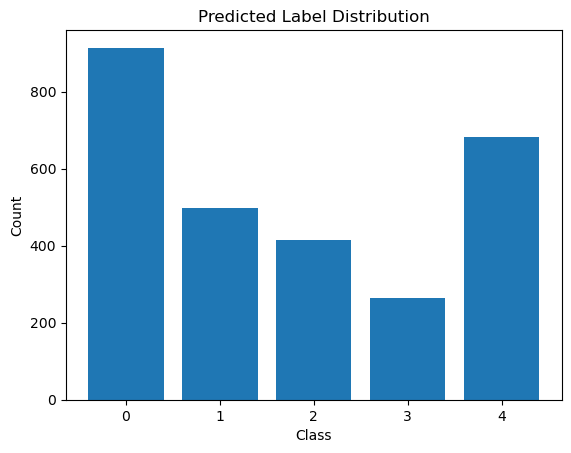

In [ ]:
from transformers import BertTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from datasets import load_dataset
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. Specify model directory (time-series FinBERT)
model_dir = "./finbert_timeseries"

# 2. Load tokenizer and model, replace classification head to 5 classes
tokenizer = BertTokenizer.from_pretrained(model_dir)
model = AutoModelForSequenceClassification.from_pretrained(
    model_dir,
    num_labels=5,                  # Replace with 5 classes
    ignore_mismatched_sizes=True   # Allow replacing classification layer
)

# 3. Load new validation set CSV
dataset = load_dataset("csv", data_files={"validation": "val_timeseries_5class.csv"})
val_dataset = dataset["validation"]

# 4. Tokenization
def tokenize(batch):
    return tokenizer(batch["text"], padding="max_length", truncation=True, max_length=512)

tokenized_val = val_dataset.map(tokenize, batched=True)
tokenized_val.set_format("torch", columns=["input_ids", "attention_mask", "label"])

# 5. Define Trainer (prediction only, no training)
training_args = TrainingArguments(
    output_dir="./tmp_eval",
    do_train=False,
    do_eval=True,
    per_device_eval_batch_size=16,
)

trainer = Trainer(
    model=model,
    args=training_args,
    eval_dataset=tokenized_val,
)

# 6. Run predictions on validation set
predictions = trainer.predict(tokenized_val)
pred_labels = predictions.predictions.argmax(-1)
true_labels = predictions.label_ids

# 7. Visualize confusion matrix
cm = confusion_matrix(true_labels, pred_labels, labels=[0,1,2,3,4])
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=[0,1,2,3,4], yticklabels=[0,1,2,3,4])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Time-series FinBERT (5-class head)")
plt.show()

# 8. Classification report
print("Classification Report - Time-series FinBERT (5-class head)")
print(classification_report(true_labels, pred_labels, labels=[0,1,2,3,4]))

unique, counts = np.unique(pred_labels, return_counts=True)
plt.bar(unique, counts)
plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Predicted Label Distribution")
plt.show()


Generating validation split: 0 examples [00:00, ? examples/s]

Map:   0%|          | 0/2774 [00:00<?, ? examples/s]

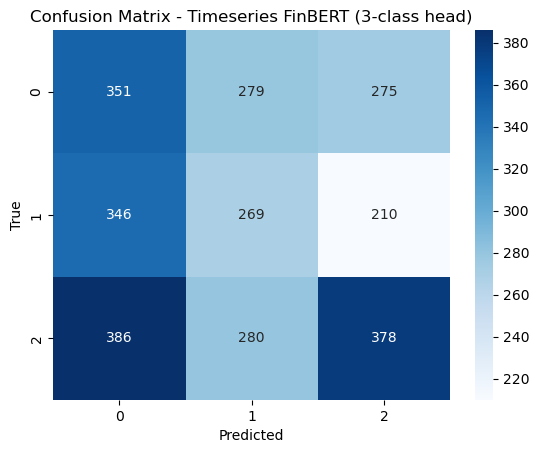

分类报告 - Timeseries FinBERT (3类头)
              precision    recall  f1-score   support

           0       0.32      0.39      0.35       905
           1       0.32      0.33      0.33       825
           2       0.44      0.36      0.40      1044

    accuracy                           0.36      2774
   macro avg       0.36      0.36      0.36      2774
weighted avg       0.37      0.36      0.36      2774



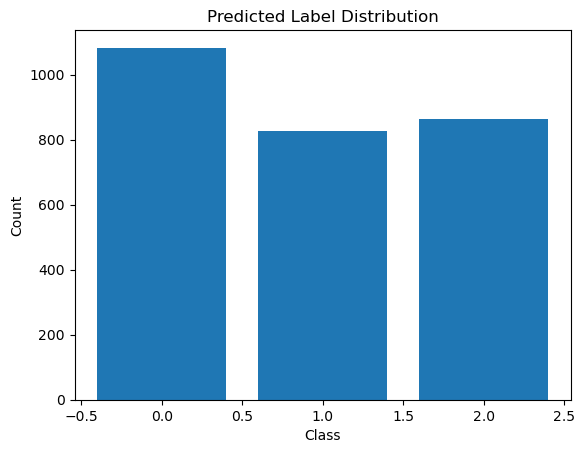

In [ ]:
import numpy as np
from transformers import BertTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from datasets import load_dataset
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. Specify model directory (time-series FinBERT)
model_dir = "./finbert_timeseries_3class"

# 2. Load tokenizer and model, replace classification head to 3 classes
tokenizer = BertTokenizer.from_pretrained(model_dir)
model = AutoModelForSequenceClassification.from_pretrained(
    model_dir,
    num_labels=3,                  # Replace with 3 classes
    ignore_mismatched_sizes=True   # Allow replacing classification layer
)

# 3. Load new validation set CSV
dataset = load_dataset("csv", data_files={"validation": "val_timeseries_3class.csv"})
val_dataset = dataset["validation"]

# 4. Tokenization
def tokenize(batch):
    return tokenizer(batch["text"], padding="max_length", truncation=True, max_length=512)

tokenized_val = val_dataset.map(tokenize, batched=True)
tokenized_val.set_format("torch", columns=["input_ids", "attention_mask", "label"])

# 5. Define Trainer (prediction only, no training)
training_args = TrainingArguments(
    output_dir="./tmp_eval",
    do_train=False,
    do_eval=True,
    per_device_eval_batch_size=16,
)

trainer = Trainer(
    model=model,
    args=training_args,
    eval_dataset=tokenized_val,
)

# 6. Run predictions on validation set
predictions = trainer.predict(tokenized_val)
pred_labels = predictions.predictions.argmax(-1)
true_labels = predictions.label_ids

# 7. Visualize confusion matrix
cm = confusion_matrix(true_labels, pred_labels, labels=[0,1,2])
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=[0,1,2], yticklabels=[0,1,2])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Time-series FinBERT (3-class head)")
plt.show()

# 8. Classification report
print("Classification Report - Time-series FinBERT (3-class head)")
print(classification_report(true_labels, pred_labels, labels=[0,1,2]))

unique, counts = np.unique(pred_labels, return_counts=True)
plt.bar(unique, counts)
plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Predicted Label Distribution")
plt.show()


In [ ]:
import os
import pandas as pd
import torch
import numpy as np
from transformers import BertTokenizer, AutoModelForSequenceClassification

# 1. Load model and tokenizer
model_dir = "./finbert_finetuned"
tokenizer = BertTokenizer.from_pretrained(model_dir)
model = AutoModelForSequenceClassification.from_pretrained(model_dir)
model.eval()

# 2. Stock code mapping
mapping = pd.read_csv(os.path.join("Eastmoney_report_pdf_download", "HS300.csv"), dtype=str)
mapping["股票代码"] = mapping["股票代码"].str.zfill(6)
name2code = dict(zip(mapping["股票简称"], mapping["股票代码"]))
code2name = dict(zip(mapping["股票代码"], mapping["股票简称"]))

# 3. Iterate through quarters
base_dir = "reports_txt_by_quarter_cleaned_en"
for quarter in os.listdir(base_dir):
    quarter_path = os.path.join(base_dir, quarter)
    if not os.path.isdir(quarter_path):
        continue
    
    results = []
    for company_name in os.listdir(quarter_path):
        company_path = os.path.join(quarter_path, company_name)
        if not os.path.isdir(company_path):
            continue
        
        if company_name not in name2code:
            continue
        stock_code = name2code[company_name]
        
        scores = []
        for root, _, files in os.walk(company_path):
            for file in files:
                if file.endswith(".txt"):
                    file_path = os.path.join(root, file)
                    try:
                        with open(file_path, "r", encoding="utf-8") as f:
                            text = f.read().strip()
                        if len(text) < 50:
                            continue
                        
                        # Tokenization
                        inputs = tokenizer(text, return_tensors="pt", truncation=True, padding="max_length", max_length=512)
                        with torch.no_grad():
                            outputs = model(**inputs)
                            logits = outputs.logits.squeeze().numpy()
                            probs = torch.softmax(outputs.logits, dim=-1).squeeze().numpy()
                        
                        # Binary classification probability
                        positive_score = float(probs[1]) if len(probs) > 1 else float(probs[0])
                        negative_score = float(probs[0]) if len(probs) > 1 else 1 - positive_score
                        avg_confidence = float(probs.max())
                        
                        scores.append([positive_score, negative_score, avg_confidence])
                    except Exception as e:
                        print(f"Skip file {file_path}: {e}")
        
        # Aggregate results for same company (take average)
        if scores:
            scores = np.array(scores)
            pos, neg, conf = scores.mean(axis=0)
        else:
            pos, neg, conf = 0, 0, 0
        
        results.append({
            "stock": stock_code,
            "name": company_name,
            "positive_score": pos,
            "negative_score": neg,
            "avg_confidence": conf
        })
    
    # 4. Save quarterly results
    df_out = pd.DataFrame(results)
    out_file = f"scores_{quarter.replace('_','')}.csv"
    df_out.to_csv(out_file, index=False)
    print(f"✅ Generated {out_file}")


In [ ]:
from transformers import BertTokenizer, AutoModelForSequenceClassification

# Use pre-trained FinBERT model
tokenizer = BertTokenizer.from_pretrained("ProsusAI/finbert")
model = AutoModelForSequenceClassification.from_pretrained(
    "ProsusAI/finbert",
    num_labels=1,   # Regression task outputs one continuous value
    ignore_mismatched_sizes=True
)

# Define tokenize function
def tokenize(batch):
    return tokenizer(batch["text"], padding="max_length", truncation=True, max_length=512)

# Assume you already have train_regression.csv and val_regression.csv
from datasets import load_dataset
dataset = load_dataset("csv", data_files={"train": "train_regression.csv", "validation": "val_regression.csv"})

# Apply tokenization
tokenized_dataset = dataset.map(tokenize, batched=True)

# Set PyTorch format, note label should be converted to float
tokenized_dataset.set_format("torch", columns=["input_ids", "attention_mask", "label"])

from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./finbert_finetuned_regression",
    do_train=True,
    do_eval=True,
    eval_strategy="epoch",   # Use old parameter name
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_dir="./logs",
    logging_steps=50,
    save_steps=500,
    eval_steps=500
)


from transformers import Trainer
import torch
import numpy as np

# Custom evaluation metrics: MSE, MAE, R2
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = predictions.squeeze()
    mse = ((predictions - labels) ** 2).mean().item()
    mae = (np.abs(predictions - labels)).mean().item()
    # R²
    ss_res = ((labels - predictions) ** 2).sum().item()
    ss_tot = ((labels - labels.mean()) ** 2).sum().item()
    r2 = 1 - ss_res / ss_tot if ss_tot != 0 else 0
    return {"mse": mse, "mae": mae, "r2": r2}

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    compute_metrics=compute_metrics
)

trainer.train()

trainer.save_model("./finbert_finetuned_regression")
tokenizer.save_pretrained("./finbert_finetuned_regression")
print("Final model saved to ./finbert_finetuned_regression")


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at ProsusAI/finbert and are newly initialized because the shapes did not match:
- classifier.weight: found shape torch.Size([3, 768]) in the checkpoint and torch.Size([1, 768]) in the model instantiated
- classifier.bias: found shape torch.Size([3]) in the checkpoint and torch.Size([1]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Map:   0%|          | 0/16825 [00:00<?, ? examples/s]

Map:   0%|          | 0/2825 [00:00<?, ? examples/s]

Epoch,Training Loss,Validation Loss,Mse,Mae,R2
1,0.096100,0.072908,0.072908,0.171171,0.015124
2,0.069400,0.068194,0.068194,0.178217,0.078794
3,0.073100,0.068245,0.068245,0.174810,0.078110


最终模型已保存到 ./finbert_finetuned_regression


In [1]:
import numpy as np

def apply_prior_std(agg, mapping):
    # Standardize stock code format
    agg["stock_code"] = agg["stock_code"].astype(str).str.zfill(6)
    agg["stock"] = agg["stock_code"]

    # Map company names
    code2name = dict(zip(mapping["股票代码"], mapping["股票简称"]))
    agg["name"] = agg["stock_code"].map(code2name)

    # Calculate market average when excluding 0-report companies
    market_std = agg.loc[agg["score_std"] > 0, "score_std"].mean(skipna=True)
    market_n_reports = agg.loc[agg["n_reports"] > 0, "n_reports"].mean()
    prior_std = market_std * np.sqrt(market_n_reports) if pd.notna(market_std) and pd.notna(market_n_reports) else 0.0

    # Single report companies (NaN → prior_std)
    agg.loc[(agg["n_reports"] == 1) & (agg["score_std"].isna()), "score_std"] = prior_std

    # Zero report companies (force to 0)
    agg.loc[agg["n_reports"] == 0, "score_std"] = 0.0

    # ✅ Keep quarter column
    agg = agg[["quarter","stock","name","score_mean","score_std","n_reports"]]
    return agg


In [ ]:
# Cell 1: Import dependencies
import os
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, AutoModelForSequenceClassification
from tqdm import tqdm
import numpy as np

# Cell 2: Configure parameters
MODEL_DIR = "./finbert_finetuned_regression"
INPUT_FILE = "backtest_regression.csv"   # Change to backtest dataset
MAPPING_FILE = os.path.join("Eastmoney_report_pdf_download", "HS300.csv")
OUTPUT_DIR = "./inference_outputs_regression"

BATCH_SIZE = 16
MAX_LENGTH = 512
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

os.makedirs(OUTPUT_DIR, exist_ok=True)

# Cell 3: Load model and tokenizer
tokenizer = BertTokenizer.from_pretrained(MODEL_DIR)
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_DIR,
    num_labels=1,
    ignore_mismatched_sizes=True
).to(DEVICE)
model.eval()

# Cell 4: Load stock mapping table (deduplication + format unification)
mapping = pd.read_csv(MAPPING_FILE, dtype=str)
mapping["股票代码"] = mapping["股票代码"].str.zfill(6)
# Deduplicate mapping table to avoid duplicate name mappings for same code
mapping = mapping.drop_duplicates(subset=["股票代码"], keep="first")

# Cell 5: Define dataset and collate function
class ReportsDataset(Dataset):
    def __init__(self, df):
        self.df = df

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        return {
            "quarter": row["quarter"],
            "stock_code": str(row["stock_code"]).zfill(6),
            "text": row["text"]
        }

def collate_fn(batch):
    texts = [b["text"] for b in batch]
    enc = tokenizer(
        texts,
        padding="max_length",
        truncation=True,
        max_length=MAX_LENGTH,
        return_tensors="pt"
    )
    return {
        "input_ids": enc["input_ids"],
        "attention_mask": enc["attention_mask"],
        "meta": batch
    }

# Cell 6: Run inference and aggregation (with duplicate diagnostics)
def run_inference_for_quarter(df_quarter):
    quarter_key = df_quarter["quarter"].iloc[0]

    # Standardize stock code format
    df_quarter = df_quarter.copy()
    df_quarter["stock_code"] = df_quarter["stock_code"].astype(str).str.zfill(6)

    ds = ReportsDataset(df_quarter)
    dl = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

    all_records = []
    with torch.no_grad():
        for batch in tqdm(dl, desc=f"Inference {quarter_key}"):
            input_ids = batch["input_ids"].to(DEVICE)
            attention_mask = batch["attention_mask"].to(DEVICE)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            preds = outputs.logits.squeeze(-1).detach().cpu().numpy()

            for meta, pred in zip(batch["meta"], preds):
                all_records.append({
                    "quarter": meta["quarter"],
                    "stock_code": meta["stock_code"],
                    "score": float(pred)
                })

    df = pd.DataFrame(all_records)

    # Diagnostic: check for duplicate raw inference records
    if not df.empty:
        dup_raw = df.duplicated(subset=["quarter","stock_code"], keep=False).sum()
        print(f"[{quarter_key}] raw inference rows={len(df)}, dup_raw={dup_raw}")

    # Aggregation to avoid duplicate rows
    if not df.empty:
        agg = df.groupby(["quarter","stock_code"])["score"].agg(["mean","std","count"]).reset_index()
        agg.rename(columns={"mean":"score_mean","std":"score_std","count":"n_reports"}, inplace=True)
    else:
        agg = pd.DataFrame(columns=["quarter","stock_code","score_mean","score_std","n_reports"])

    # Diagnostic: check for remaining duplicates after aggregation
    dup_agg = agg.duplicated(subset=["quarter","stock_code"], keep=False).sum()
    print(f"[{quarter_key}] after groupby rows={len(agg)}, dup_agg={dup_agg}")

    # === Fill missing companies with neutral values ===
    # Note: after deduplication of mapping, avoid duplicate padding
    neutral_rows = []
    present = set(agg["stock_code"])
    for code in mapping["股票代码"]:
        if code not in present:
            neutral_rows.append({
                "quarter": quarter_key,
                "stock_code": code,
                "score_mean": 0.0,
                "score_std": 0.0,
                "n_reports": 0
            })
    if neutral_rows:
        agg = pd.concat([agg, pd.DataFrame(neutral_rows)], ignore_index=True)

    # Diagnostic: check for duplicates after neutral fill
    dup_after_neutral = agg.duplicated(subset=["quarter","stock_code"], keep=False).sum()
    print(f"[{quarter_key}] after neutral rows={len(agg)}, dup_after_neutral={dup_after_neutral}")

    # Call encapsulated function to handle stock/name/std (no new rows added)
    agg = apply_prior_std(agg, mapping)

    # Final deduplication (safety guarantee)
    before_final = len(agg)
    agg = agg.sort_values(["quarter","stock"]).drop_duplicates(subset=["quarter","stock"], keep="first")
    after_final = len(agg)
    print(f"[{quarter_key}] final rows={after_final}, dropped={before_final - after_final}")

    out_file = os.path.join(OUTPUT_DIR, f"scores_{quarter_key}.csv")
    agg.to_csv(out_file, index=False)
    print(f"✅ Saved {out_file}")
    return agg

# Cell 7: Main workflow
df_all = pd.read_csv(INPUT_FILE)
# Standardize stock code format to avoid inconsistency in downstream
df_all["stock_code"] = df_all["stock_code"].astype(str).str.zfill(6)
quarters = sorted(df_all["quarter"].unique())

for q in quarters:
    df_q = df_all[df_all["quarter"] == q]
    run_inference_for_quarter(df_q)


Inference 2017Q1: 100%|██████████| 7/7 [00:01<00:00,  4.54it/s]


[2017Q1] raw inference rows=104, dup_raw=62
[2017Q1] after groupby rows=67, dup_agg=0
[2017Q1] after neutral rows=300, dup_after_neutral=0
[2017Q1] final rows=300, dropped=0
✅ Saved ./inference_outputs_regression\scores_2017Q1.csv


Inference 2017Q2: 100%|██████████| 9/9 [00:02<00:00,  4.30it/s]


[2017Q2] raw inference rows=140, dup_raw=82
[2017Q2] after groupby rows=89, dup_agg=0
[2017Q2] after neutral rows=300, dup_after_neutral=0
[2017Q2] final rows=300, dropped=0
✅ Saved ./inference_outputs_regression\scores_2017Q2.csv


Inference 2017Q3: 100%|██████████| 12/12 [00:02<00:00,  4.43it/s]


...

[2025Q2] raw inference rows=256, dup_raw=178
[2025Q2] after groupby rows=141, dup_agg=0
[2025Q2] after neutral rows=300, dup_after_neutral=0
[2025Q2] final rows=300, dropped=0
✅ Saved ./inference_outputs_regression\scores_2025Q2.csv


Inference 2025Q3: 100%|██████████| 17/17 [00:03<00:00,  5.25it/s]


[2025Q3] raw inference rows=261, dup_raw=170
[2025Q3] after groupby rows=157, dup_agg=0
[2025Q3] after neutral rows=300, dup_after_neutral=0
[2025Q3] final rows=300, dropped=0
✅ Saved ./inference_outputs_regression\scores_2025Q3.csv


Inference 2025Q4: 100%|██████████| 12/12 [00:02<00:00,  5.97it/s]

[2025Q4] raw inference rows=180, dup_raw=112
[2025Q4] after groupby rows=114, dup_agg=0
[2025Q4] after neutral rows=300, dup_after_neutral=0
[2025Q4] final rows=300, dropped=0
✅ Saved ./inference_outputs_regression\scores_2025Q4.csv
